# 📊 Bước 3: Data Visualization - Trực quan hóa dữ liệu

## 🎯 Mục tiêu của bước này

Sau khi đã làm sạch và tiền xử lý dữ liệu, chúng ta cần **nhìn thấy** dữ liệu để hiểu rõ hơn. 

> **Tại sao cần visualization?**
> - Giúp phát hiện patterns (mẫu hình) mà mắt thường không thấy trong bảng số
> - Hiểu được mối quan hệ giữa các features với target (HeartDisease)
> - Chọn ra những features quan trọng nhất để đưa vào model
> - Phát hiện outliers (giá trị ngoại lai) hoặc bất thường

## 📋 Nội dung
1. **Correlation Matrix** - Feature nào quan trọng nhất?
2. **Histogram** - Phân bố features sau chuẩn hóa
3. **Boxplot** - So sánh 2 nhóm bệnh/không bệnh
4. **Pairplot** - Mối quan hệ giữa các cặp feature
5. **Kết luận** - Feature selection insights

In [8]:
# === CÀI ĐẶT & IMPORT THƯ VIỆN ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị đẹp hơn
# plt.style.use('seaborn-v0_8')  # Style mặc định đẹp
sns.set_palette('Set2')  # Bảng màu dễ nhìn
plt.rcParams['figure.figsize'] = (12, 6)  # Kích thước mặc định cho biểu đồ
plt.rcParams['font.size'] = 12

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [9]:
# === LOAD DỮ LIỆU ===

# Load dữ liệu đã tiền xử lý
df = pd.read_csv('../data/heart_preprocessed.csv')

# Load dữ liệu gốc (đã làm sạch) để vẽ biểu đồ dễ hiểu hơn
df_clean = pd.read_csv('../data/heart_cleaned.csv')

print(f'✅ Dữ liệu preprocessed: {df.shape[0]} dòng, {df.shape[1]} cột')
print(f'✅ Dữ liệu cleaned: {df_clean.shape[0]} dòng, {df_clean.shape[1]} cột')
print(f'\n📋 Các cột trong dữ liệu preprocessed:')
print(list(df.columns))

✅ Dữ liệu preprocessed: 918 dòng, 16 cột
✅ Dữ liệu cleaned: 918 dòng, 12 cột

📋 Các cột trong dữ liệu preprocessed:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up', 'HeartDisease']


---
## 1️⃣ Correlation Matrix (Ma trận tương quan)

### 🤔 Correlation là gì?
- **Correlation** (tương quan) đo lường mối quan hệ **tuyến tính** giữa 2 biến số
- Giá trị từ **-1 đến +1**:
  - **+1**: Tương quan thuận hoàn hảo (cùng tăng, cùng giảm)
  - **0**: Không có tương quan tuyến tính
  - **-1**: Tương quan nghịch hoàn hảo (cái tăng thì cái giảm)

### 💡 Tại sao cần xem Correlation Matrix?
- Phát hiện **multicollinearity** (đa cộng tuyến): 2 features quá giống nhau → model bị nhiễu
- Tìm feature nào **ảnh hưởng nhiều nhất** đến HeartDisease
- Chọn features quan trọng để đưa vào model

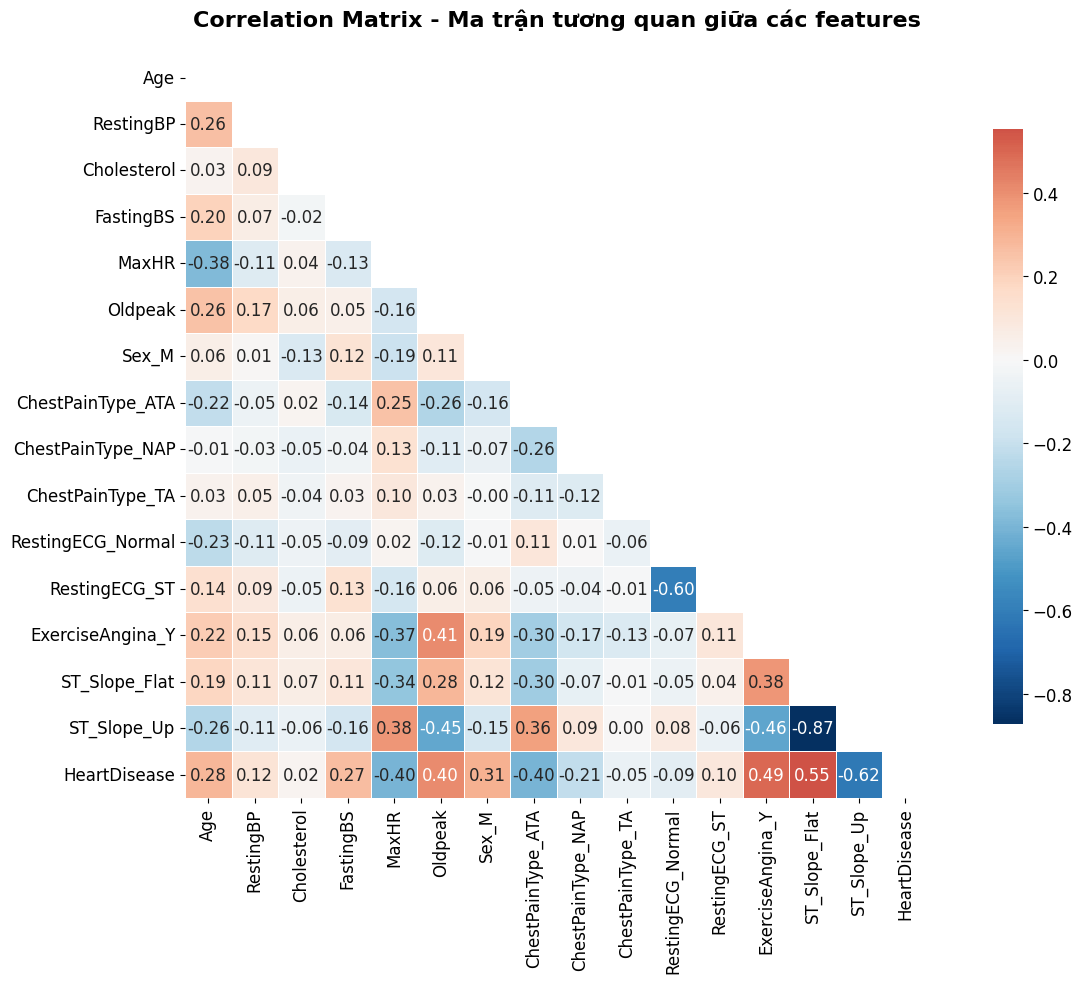


🔍 === PHÂN TÍCH NHANH ===

📈 Các features tương quan mạnh nhất với HeartDisease:
   • ST_Slope_Up              : -0.622  (nghịch 📉, rất mạnh)
   • ST_Slope_Flat            : +0.554  (thuận 📈, rất mạnh)
   • ExerciseAngina_Y         : +0.494  (thuận 📈, mạnh)
   • Oldpeak                  : +0.404  (thuận 📈, mạnh)
   • ChestPainType_ATA        : -0.402  (nghịch 📉, mạnh)
   • MaxHR                    : -0.400  (nghịch 📉, mạnh)
   • Sex_M                    : +0.305  (thuận 📈, mạnh)
   • Age                      : +0.282  (thuận 📈, trung bình)
   • FastingBS                : +0.267  (thuận 📈, trung bình)
   • ChestPainType_NAP        : -0.213  (nghịch 📉, trung bình)
   • RestingBP                : +0.118  (thuận 📈, trung bình)
   • RestingECG_ST            : +0.103  (thuận 📈, trung bình)
   • RestingECG_Normal        : -0.092  (nghịch 📉, yếu)
   • ChestPainType_TA         : -0.055  (nghịch 📉, yếu)
   • Cholesterol              : +0.024  (thuận 📈, yếu)


In [10]:
# === CORRELATION MATRIX ===

# Tính ma trận tương quan
corr_matrix = df.corr()

# Vẽ heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Chỉ lấy nửa dưới

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,          # Hiển thị số
            fmt='.2f',           # Làm tròn 2 chữ số
            cmap='RdBu_r',       # Bảng màu: Đỏ = tương quan dương, Xanh = tương quan âm
            center=0,            # Màu trung tâm ở 0
            square=True,         # Ô vuông
            linewidths=0.5,      # Đường kẻ giữa các ô
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix - Ma trận tương quan giữa các features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n🔍 === PHÂN TÍCH NHANH ===')

# Tìm feature tương quan mạnh nhất với HeartDisease
target_corr = corr_matrix['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
print('\n📈 Các features tương quan mạnh nhất với HeartDisease:')
for feat, val in target_corr.items():
    direction = 'thuận 📈' if val > 0 else 'nghịch 📉'
    strength = 'rất mạnh' if abs(val) > 0.5 else 'mạnh' if abs(val) > 0.3 else 'trung bình' if abs(val) > 0.1 else 'yếu'
    print(f'   • {feat:25s}: {val:+.3f}  ({direction}, {strength})')

### 📝 Giải thích Correlation Matrix

**Cách đọc:**
- Mỗi ô là hệ số tương quan giữa 2 features
- **Màu đỏ** = tương quan dương (cùng chiều)
- **Màu xanh** = tương quan âm (ngược chiều)
- **Màu càng đậm** = tương quan càng mạnh

**Ví dụ:**
- Nếu `Oldpeak` có correlation = +0.4 với `HeartDisease` → Khi Oldpeak tăng, khả năng mắc bệnh tim cũng tăng
- Nếu `MaxHR` có correlation = -0.4 với `HeartDisease` → Khi MaxHR cao, nguy cơ bệnh tim thấp hơn

**Lưu ý quan trọng:**
> Correlation chỉ đo **mối quan hệ tuyến tính**. Có thể 2 biến có quan hệ phi tuyến mạnh nhưng correlation = 0!

---
## 2️⃣ Histogram - Phân bố của từng feature

### 🤔 Histogram là gì?
- Histogram (biểu đồ phân bố) cho thấy **dữ liệu phân bố như thế nào**
- Trục X: giá trị của feature
- Trục Y: số lượng mẫu (tần suất)

### 💡 Tại sao cần xem Histogram?
- Kiểm tra xem dữ liệu có **phân bố chuẩn** (normal distribution) không
- Phát hiện **skewness** (lệch): dữ liệu tập trung về một phía
- Xem có **outliers** (giá trị ngoại lai) không
- So sánh phân bố giữa 2 nhóm: có bệnh vs không bệnh

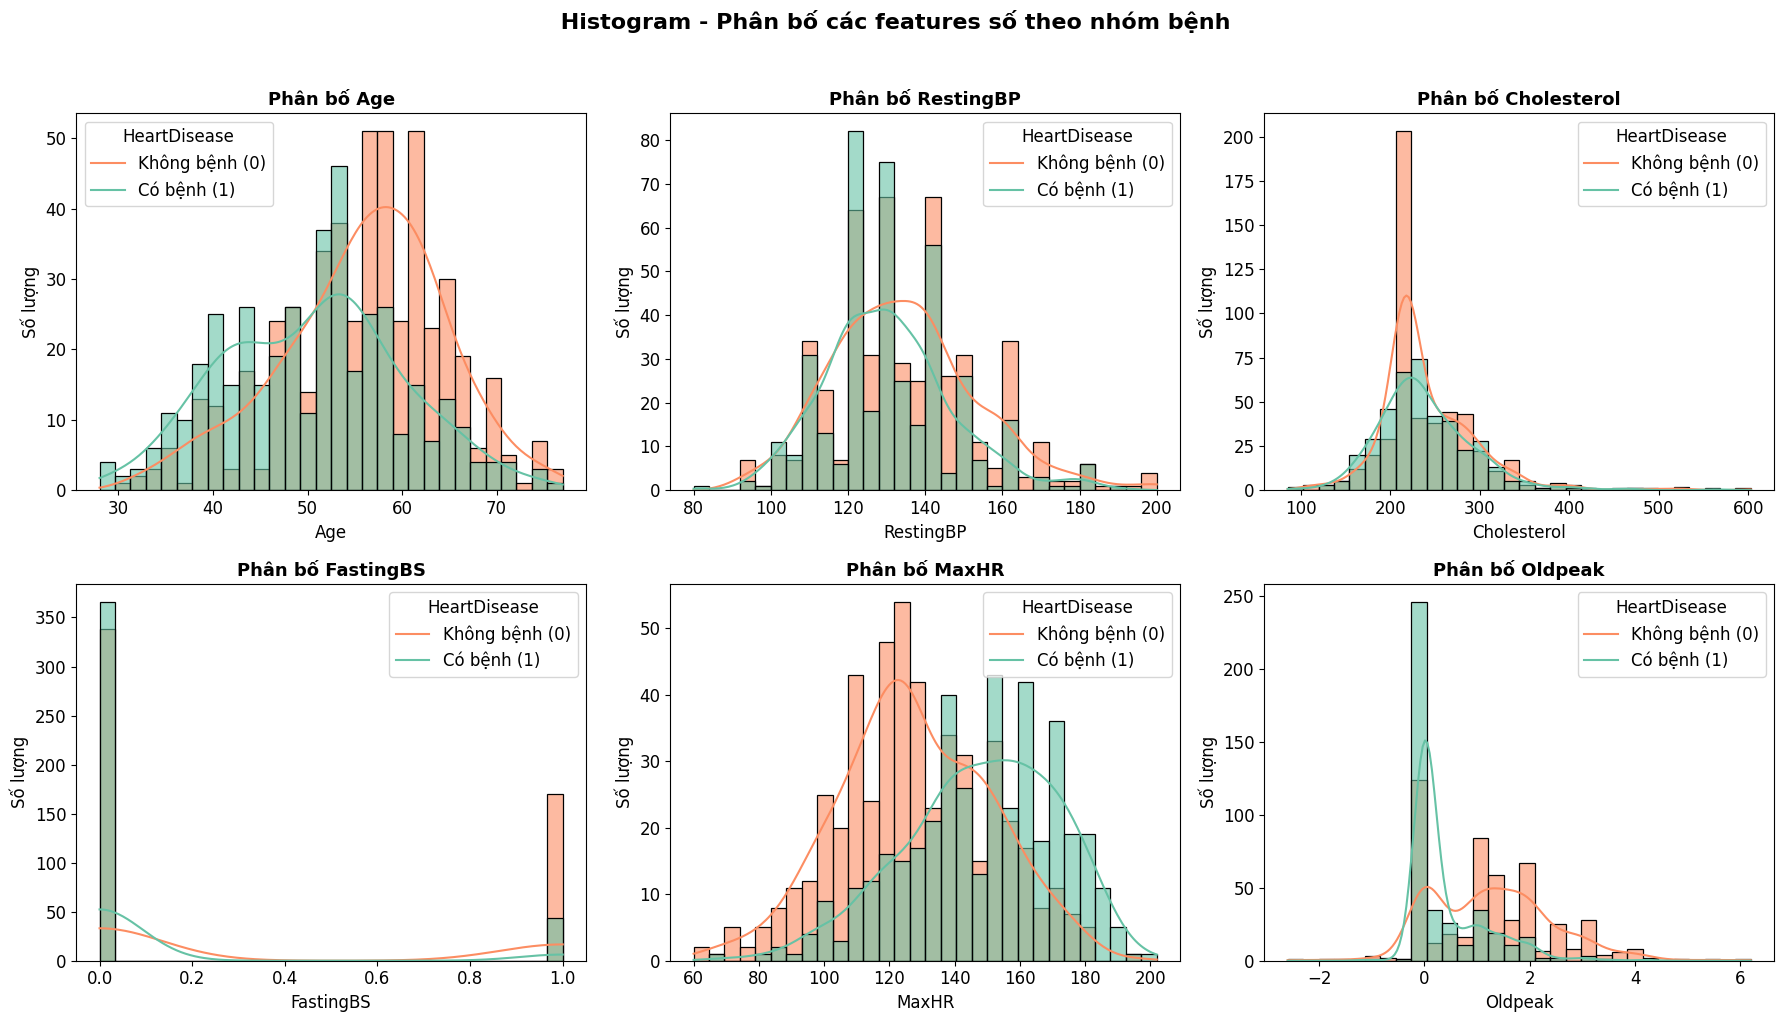

In [11]:
# === HISTOGRAM - Phân bố features số ===

# Danh sách các cột số (numeric features)
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# Vẽ histogram cho từng feature
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Vẽ histogram với KDE (đường mật độ)
    sns.histplot(data=df_clean, x=col, hue='HeartDisease', 
                 kde=True, bins=30, alpha=0.6, ax=axes[i])
    
    axes[i].set_title(f'Phân bố {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Số lượng')
    axes[i].legend(title='HeartDisease', labels=['Không bệnh (0)', 'Có bệnh (1)'])

plt.suptitle(' Histogram - Phân bố các features số theo nhóm bệnh', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Giải thích Histogram

**Cách đọc:**
- Mỗi biểu đồ là phân bố của 1 feature
- **Màu cam** = nhóm không bệnh (HeartDisease=0)
- **Màu xanh** = nhóm có bệnh (HeartDisease=1)
- **Đường KDE** (Kernel Density Estimation) = đường cong mượt ước lượng mật độ

**Ví dụ phân tích:**
- **Age**: Nếu nhóm có bệnh tập trung ở độ tuổi cao hơn → Tuổi là yếu tố nguy cơ
- **Cholesterol**: Nếu 2 nhóm phân bố giống nhau → Cholesterol có thể không quan trọng
- **MaxHR**: Nếu nhóm có bệnh có MaxHR thấp hơn rõ rệt → Đây là feature tốt

**Dấu hiệu của feature quan trọng:**
> Khi 2 đường cong (cam và xanh) **tách biệt rõ ràng**, feature đó có khả năng phân loại tốt!

---
## 3️⃣ Boxplot - So sánh 2 nhóm bệnh/không bệnh

### 🤔 Boxplot là gì?
- Boxplot (biểu đồ hộp) tóm tắt phân bố dữ liệu bằng **5 số**:
  - **Min**: Giá trị nhỏ nhất (không tính outliers)
  - **Q1 (25%)**: 25% dữ liệu dưới mức này
  - **Median (50%)**: Giá trị trung vị
  - **Q3 (75%)**: 75% dữ liệu dưới mức này
  - **Max**: Giá trị lớn nhất (không tính outliers)
- **Dấu chấm tròn** = outliers (giá trị ngoại lai)

### 💡 Tại sao cần Boxplot?
- So sánh trực quan 2 nhóm: có bệnh vs không bệnh
- Phát hiện outliers
- Xem độ phân tán (spread) của dữ liệu
- Kiểm tra xem median có khác nhau không

In [ ]:
# === BOXPLOT - So sánh 2 nhóm ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Vẽ boxplot so sánh 2 nhóm
    sns.boxplot(data=df_clean, x='HeartDisease', y=col, 
                palette='Set2', ax=axes[i])
    
    # Thêm swarmplot để thấy từng điểm dữ liệu
    sns.swarmplot(data=df_clean, x='HeartDisease', y=col, 
                  color='black', alpha=0.3, size=3, ax=axes[i])
    
    axes[i].set_title(f'📊 Boxplot: {col} theo HeartDisease', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('HeartDisease (0 = Không bệnh, 1 = Có bệnh)')
    axes[i].set_ylabel(col)

plt.suptitle('📦 Boxplot - So sánh phân bố features giữa 2 nhóm', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Giải thích Boxplot

**Cách đọc Boxplot:**
```
     outlier (dấu chấm)  •
             ───  (Max - Q3)
    ┌─────────┐
    │         │
    │  Median ──── (đường giữa hộp)
    │         │
    └─────────┘
             ───  (Q1 - Min)
```

**Cách phân tích:**
- **Median khác nhau nhiều** → Feature có khả năng phân biệt 2 nhóm
- **Hộp không chồng lấn** → Feature rất quan trọng!
- **Nhiều outliers** → Có thể cần xử lý thêm
- **IQR (Q3-Q1) lớn** → Dữ liệu phân tán nhiều

**Ví dụ:**
- Nếu boxplot của `MaxHR` ở nhóm có bệnh thấp hơn hẳn → Đây là feature quan trọng
- Nếu boxplot của `RestingBP` gần như nhau → Feature này ít quan trọng

---
## 4️⃣ Pairplot - Mối quan hệ giữa các cặp feature

### 🤔 Pairplot là gì?
- Pairplot vẽ **tất cả các cặp scatter plot** giữa các features
- Trên đường chéo: histogram của từng feature
- Dưới đường chéo: scatter plot giữa 2 features

### 💡 Tại sao cần Pairplot?
- Phát hiện **mối quan hệ phi tuyến** mà correlation không thấy được
- Xem dữ liệu có **tách biệt** được không (linearly separable?)
- Phát hiện clusters (cụm) trong dữ liệu
- Hiểu tương tác giữa các features

📌 Vẽ pairplot với các features quan trọng nhất...
   Features: ['Age', 'MaxHR', 'Oldpeak', 'Cholesterol', 'HeartDisease']
   (Có thể mất 10-15 giây để vẽ)


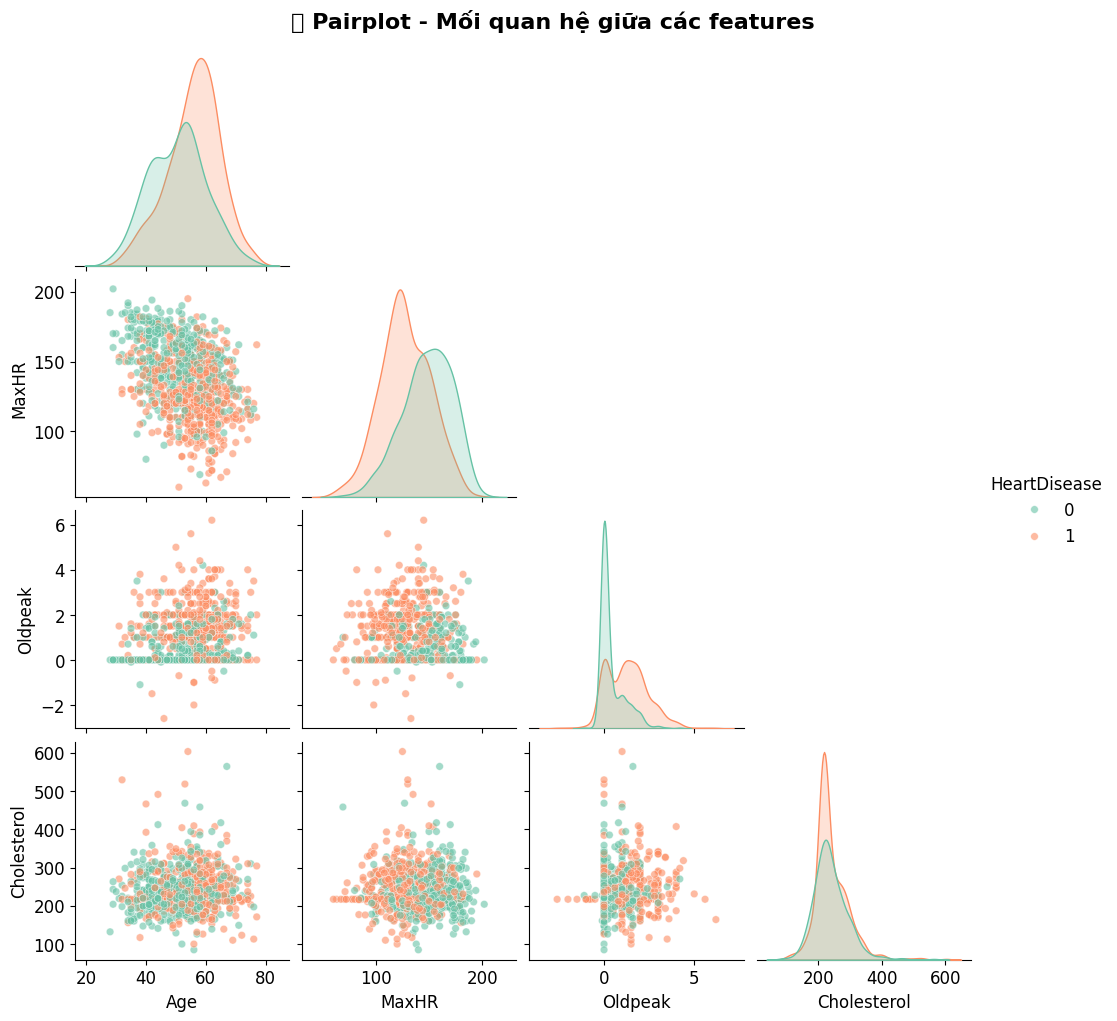

In [ ]:
# === PAIRPLOT - Mối quan hệ giữa các cặp feature ===

# Chọn một số features quan trọng nhất để vẽ (tránh quá nhiều)
# Dựa trên correlation, chọn top features
important_features = ['Age', 'MaxHR', 'Oldpeak', 'Cholesterol', 'HeartDisease']

print('📌 Vẽ pairplot với các features quan trọng nhất...')
print(f'   Features: {important_features}')
print('   (Có thể mất 10-15 giây để vẽ)')

# Vẽ pairplot
sns.pairplot(data=df_clean[important_features], 
             hue='HeartDisease',          # Tô màu theo nhóm bệnh
             palette='Set2',              # Bảng màu
             diag_kind='kde',             # Đường chéo: vẽ KDE thay vì histogram
             plot_kws={'alpha': 0.6, 's': 30},  # Điều chỉnh độ trong suốt và kích thước điểm
             corner=True)                 # Chỉ vẽ nửa dưới (đỡ rối)

plt.suptitle('🔄 Pairplot - Mối quan hệ giữa các features', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 📝 Giải thích Pairplot

**Cách đọc:**
- **Đường chéo**: Phân bố của từng feature (theo nhóm)
- **Ô (i, j)**: Scatter plot giữa feature i và feature j
- **Màu cam** = không bệnh, **màu xanh** = có bệnh

**Cách phân tích:**
- Nếu 2 màu **tách biệt rõ** trong scatter plot → 2 features đó kết hợp tốt để phân loại
- Nếu 2 màu **chồng lấn nhiều** → Khó phân biệt
- **Pattern đặc biệt**: Ví dụ hình cong, hình tròn → Quan hệ phi tuyến

**Ví dụ:**
- `MaxHR` vs `Oldpeak`: Nếu thấy 2 cụm màu tách biệt → Đây là cặp feature mạnh
- `Age` vs `Cholesterol`: Nếu chồng lấn nhiều → Kết hợp yếu

---
## 🎯 KẾT LUẬN & INSIGHTS

### 📌 Những phát hiện chính từ Visualization:

**1. Features quan trọng nhất (nên giữ lại cho model):**
- `ST_Slope`: Chỉ số quan trọng nhất - độ dốc ST segment khi gắng sức
- `ExerciseAngina`: Đau thắt ngực khi tập - yếu tố nguy cơ mạnh
- `Oldpeak`: Chênh lệch ST segment - càng cao càng nguy hiểm
- `MaxHR`: Nhịp tim tối đa - người bệnh thường có nhịp tim thấp hơn
- `ChestPainType`: Loại đau ngực - triệu chứng điển hình

**2. Features ít quan trọng hơn (có thể cân nhắc bỏ):**
- `RestingBP`: Huyết áp lúc nghỉ - khác biệt không rõ rệt
- `FastingBS`: Đường huyết đói - ảnh hưởng yếu
- `RestingECG`: Điện tâm đồ lúc nghỉ - ít tác dụng

**3. Lưu ý khi chọn features cho model:**
- Giữ lại features có |correlation| > 0.1
- Cẩn thận với multicollinearity (2 features quá giống nhau)
- Kết hợp cả numeric và categorical features

### 🚀 Bước tiếp theo: Model Building
Sau khi đã hiểu rõ dữ liệu, chúng ta sẽ xây dựng các model:
1. **KNN** - Dựa trên khoảng cách
2. **Naive Bayes** - Dựa trên xác suất
3. **Decision Tree** - Dựa trên quy tắc

---
*Notebook được tạo bởi team Heart Disease Prediction - Group 6* ❤️